In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df_3 = pd.read_csv("results/AutoEncoder/paper_run_3.csv").mean(numeric_only=True).round(3) * 100
df_4 = pd.read_csv("results/AutoEncoder/paper_run_4.csv").mean(numeric_only=True).round(3) * 100
df_5 = pd.read_csv("results/AutoEncoder/paper_run_5.csv").mean(numeric_only=True).round(3) * 100
df_6 = pd.read_csv("results/AutoEncoder/paper_run_6.csv").mean(numeric_only=True).round(3) * 100
df_7 = pd.read_csv("results/AutoEncoder/paper_run_7.csv").mean(numeric_only=True).round(3) * 100

In [16]:
df = (df_3+df_4+df_5+df_6+df_7)/5
df = df.round(1)
df

score_top1     52.7
score_top2     54.8
score_top3     57.1
score_top4     58.6
score_top5     59.9
score_top6     61.0
score_top7     62.9
score_top8     64.6
score_top9     66.0
score_top10    66.9
dtype: float64

In [39]:
df = pd.read_csv("results/AutoEncoder/paper_run_3.csv")
df

,filename,score_top1,score_top2,score_top3,score_top4,score_top5,score_top6,score_top7,score_top8,score_top9,score_top10
0,246_UCR_Anomaly_tilt12755mtable_100211_270800_...,0,0,0,0,0,0,0,0,0,0
1,205_UCR_Anomaly_CHARISfive_9812_28995_29085.txt,0,0,0,0,0,1,1,1,1,1
2,137_UCR_Anomaly_InternalBleeding18_2300_4485_4...,1,1,1,1,1,1,1,1,1,1
3,232_UCR_Anomaly_mit14134longtermecg_8763_57530...,1,1,1,1,1,1,1,1,1,1
4,125_UCR_Anomaly_ECG4_5000_17000_17100.txt,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
245,015_UCR_Anomaly_DISTORTEDECG4_5000_16800_17100...,1,1,1,1,1,1,1,1,1,1
246,221_UCR_Anomaly_STAFFIIIDatabase_45616_163632_...,1,1,1,1,1,1,1,1,1,1
247,005_UCR_Anomaly_DISTORTEDCIMIS44AirTemperature...,1,1,1,1,1,1,1,1,1,1
248,130_UCR_Anomaly_GP711MarkerLFM5z4_4000_6527_66...,1,1,1,1,1,1,1,1,1,1


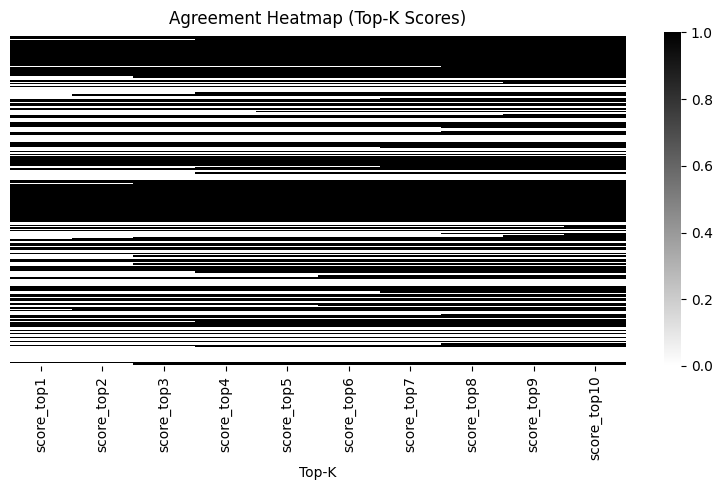

In [40]:

df_sorted = df_ex.sort_values(by="filename")
score_cols = [col for col in df_ex.columns if col.startswith("score_")]
data = df_sorted[score_cols]

plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="binary", vmin=0, vmax=1, yticklabels=False)

plt.title("Agreement Heatmap (Top-K Scores)")
plt.xlabel("Top-K")
plt.ylabel("")  
plt.tight_layout()
plt.show()

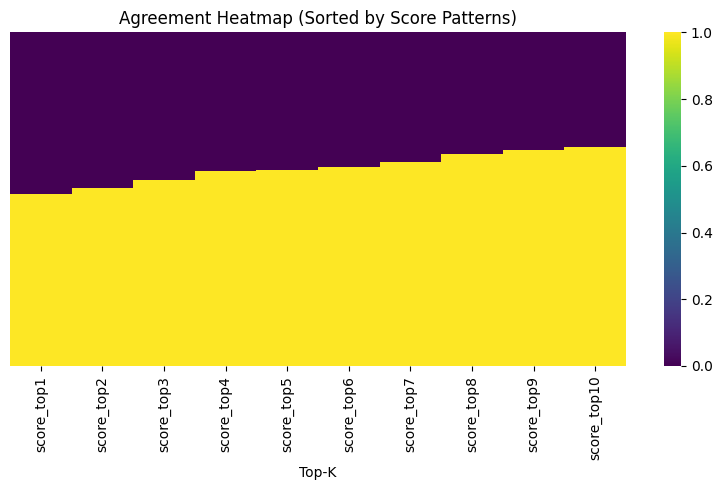

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select score columns
score_cols = [col for col in df.columns if col.startswith("score_")]

# Sort by score pattern (all columns)
df_sorted = df.sort_values(by=score_cols)

# Keep only score data
data = df_sorted[score_cols].reset_index(drop=True)

# Plot
plt.figure(figsize=(8, 5))
sns.heatmap(
    data,
    cmap="viridis",   # better than black/white
    vmin=0, vmax=1,
    yticklabels=False,
    cbar=True
)

plt.title("Agreement Heatmap (Sorted by Score Patterns)")
plt.xlabel("Top-K")
plt.tight_layout()
plt.show()

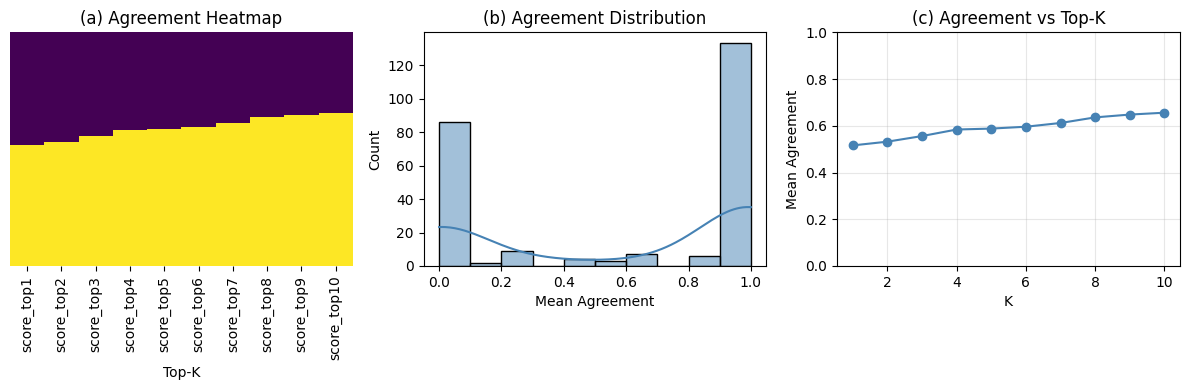

In [77]:
score_cols = [col for col in df.columns if col.startswith("score_")]
df_sorted = df.sort_values(by=score_cols)
data = df_sorted[score_cols].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax1, ax2, ax3 = axes
sns.heatmap(
    data,
    cmap="viridis",
    vmin=0, vmax=1,
    cbar=False,
    ax=ax1
)
ax1.set_title("(a) Agreement Heatmap")
ax1.set_xlabel("Top-K")
ax1.set_ylabel("")
ax1.set_yticks([])
sns.histplot(
    data.mean(axis=1),
    bins=10,
    kde=True,
    ax=ax2,
    color="steelblue"
)

ax2.set_title("(b) Agreement Distribution")
ax2.set_xlabel("Mean Agreement")
ax2.set_ylabel("Count")
ax3.plot(range(1, len(score_cols) + 1), data.mean(axis=0), marker="o", color="steelblue")

ax3.set_title("(c) Agreement vs Top-K")
ax3.set_xlabel("K")
ax3.set_ylabel("Mean Agreement")
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.3)
plt.tight_layout()

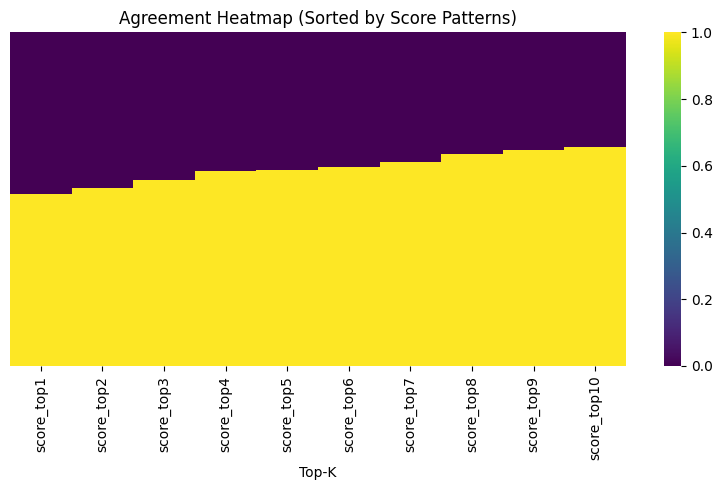

In [64]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    data,
    cmap="viridis",   # better than black/white
    vmin=0, vmax=1,
    yticklabels=False,
    cbar=True
)

plt.title("Agreement Heatmap (Sorted by Score Patterns)")
plt.xlabel("Top-K")
plt.tight_layout()
plt.show()